# Day 03 – Exploring the `seisio` Library for Seismic Data

## Introduction

On Day 03 of my **100 Days of Python for Oil & Gas / Geophysics** journey, I explored the **`seisio` library**, a Python package designed for reading and writing seismic data in common geophysical formats.

In geophysics and seismic processing, data are usually stored in formats such as:

- **SEG-Y**
- **Seismic Unix (SU)**
- **SEG2**

The `seisio` library provides a **simple and flexible way to perform I/O operations on these seismic files using Python**.

The library was created mainly for **students and researchers in geophysics**, making it easier to experiment with seismic data without complicated dependencies.

---

## What is `seisio`?

`seisio` is a **pure Python seismic I/O module** that allows users to:

- Read seismic traces
- Access trace headers
- Write seismic data files
- Process seismic datasets efficiently

It supports both **2D and 3D seismic data** and does **not assume any fixed geometry**, making it flexible for many types of seismic datasets.

---

## Supported Seismic Data Formats

`seisio` can work with several standard seismic formats used in geophysical exploration:

| Format | Description |
|------|------|
| **SEG-Y** | Standard seismic data format used in exploration geophysics |
| **SU (Seismic Unix)** | Open seismic processing format widely used in research |
| **SEG2** | Often used for near-surface seismic surveys |

---

## Key Features of `seisio`

Some important capabilities of the library include:

- Read and write **SEG-Y files (including SEG-Y rev. 2.1)**
- Read and write **Seismic Unix (SU) files**
- Read **SEG2 seismic data**
- Supports **IBM and IEEE floating point formats**
- **Lazy loading** (data is loaded only when required)
- Automatic detection of:
  - **Endian byte order**
  - **Text header encoding (ASCII / EBCDIC)**
- Flexible **trace header customization**
- Ability to read traces in **any order**
- Efficient handling of **large seismic datasets**

---

# Read and Analyse segy data

In [4]:
import logging
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

import sys
sys.path.insert(1, '../')

In [5]:
import seisio

In [81]:
#segy_file="/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/Day-o3/three_traces.sgy"
segy_file="/home/ashraf/Downloads/ST8511r92.segy"

In [82]:
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s: %(message)s",
    force=True
)

In [83]:
sio=seisio.input(segy_file)

INFO: Input file: /home/ashraf/Downloads/ST8511r92.segy
INFO: SEG-Y textual file header encoding looks to be 'EBCDIC' (best guess).
INFO: Input file endianess looks to be '>' (best guess).
INFO: SEG-Y revision: original SEG-Y conforming to 1975 standard.
INFO: Data sample format: 4-byte IEEE floating-point.
INFO: Number of additional textual header records: 0.
INFO: Number of trailer stanza records: 0.
INFO: SEG-Y trace header extension 1 is not present.
INFO: Number of user-defined trace headers: 0
INFO: Byte offset of first trace relative to start of file: 3600 bytes.
INFO: Number of samples per data trace: 227.
INFO: Sampling interval: 4003 (unit as per SEG-Y standard).
INFO: Number of data traces in file: 112875.
INFO: Delay (on first trace): 0 (unit as per SEG-Y standard).


In [84]:
file_endianess = sio.endianess       # file endianess, little or big endian
file_name = sio.file                 # file name
file_size = sio.fsize                # file size in bytes
trace_header_size = sio.thsize       # size in bytes of a single trace header
trace_header_keys = sio.mnemonics    # list of trace header mnemonics
trace_size = sio.trsize              # size in bytes of a single complete trace
nsamples = sio.nsamples              # number of samples per trace; or sio.ns for short
ntraces = sio.ntraces                # total number of traces in file; or sio.nt for short
sampling_interval = sio.vsi          # sampling interval (usually in microsec) along vertical axis
sampling_times = sio.vaxis           # vector of sampling times (vertical axis)
recording_delay = sio.delay          # delay recording time of first trace (usually in millisec)
ntxtrecord = sio.ntxtrec             # number of additional textual header records
ntxtrailer = sio.ntxtrail            # number of textual trailer records
nthuser = sio.nthuser                # number of user-defined trace headers
trace_header_ext1 = sio.thext1       # flag whether trace header extension 1 is present
textual_file_header = sio.txthead    # primary SEG-Y textual file header (decoded if necessary)
binary_file_header = sio.binhead     # SEG-Y binary file header

### log the content of the primary SEG-Y textual header

In [85]:
txthead=sio.log_txthead()

INFO: SEG-Y textual file header:
INFO: -------- BEGIN --------
C 1 SEGY OUTPUT FROM Petrel 2004 alpha Tuesday, November 09 2004 14:28:46       
C 2 Name: ST8511r92 Type: 3D Seismic                                            
C 3 First inline: 152    Last inline: 900                                       
C 4 First xline:  150    Last xline:  750                                       
C 5 X min: 451187.18 max: 458842.61 delta: 7655.43                              
C 6 Y min: 6780245.45 max: 6789707.30 delta: 9461.85                            
C 7 Time min: -2304.72 max: -1396.00 delta: 908.73                              
C 8 Trace min: -2302.72 max: -1398.00 delta: 904.72                             
C 9 Seismic min: -12306.85 max: 11257.89 delta: 23564.73                        
C10 Amplitude min: -12306.85 max: 11257.89 delta: 23564.73                      
C11 Trace sample format: IEEE floating point                                    
C12 Binary header locations:                  

##  log the binary file header

In [86]:
binary_file_header=sio.log_binhead()

INFO: SEG-Y binary file header:
+---------+---------+----------------------------------------------------------+
|         |   value | description                                              |
|---------+---------+----------------------------------------------------------|
| job     |       1 | Job identification number                                |
| line    |       1 | Line number                                              |
| reel    |       1 | Reel number                                              |
| nt      |       1 | Number of traces per ensemble                            |
| dt      |    4003 | Sample interval                                          |
| dtorig  |       1 | Sample interval of original field recording              |
| ns      |     227 | Number of samples per trace                              |
| nsorig  |       1 | Number of samples per trace for original field recording |
| format  |       5 | Data sample format code                                

## Read trace header

In [88]:
trace_headers=sio.read_all_headers()

INFO: Reading all 112875 trace headers from disk...
INFO: Reading all headers took 0.1 seconds.


## Now we can determine some trace header statistics to get a good overview of the data set at hand. As we have already read the trace headers from disk, we can make those headers available to the log_thstat() method, otherwise the method would read the trace headers from disk itself.

In [89]:
TRACE_HEADER_STAT = sio.log_thstat(traces=trace_headers)


INFO: Calculating trace header statistics.
INFO: Summary of trace header statistics (zeros excluded):
+--------+------------------+------------------+------------------+----------------+------------------+------------------+
|        |              min |              max |             mean |            std |              25% |              75% |
|--------+------------------+------------------+------------------+----------------+------------------+------------------|
| tracl  |      1           |    301           |    151           |   86.8911      |     76           |    226           |
| tracr  |    152           |    900           |    526           |  216.507       |    338           |    714           |
| tracf  |      1           |    301           |    151           |   86.8911      |     76           |    226           |
| cdp    |    150           |    750           |    450           |  173.782       |    300           |    600           |
| cdpt   |      1           |      1.

In [90]:
sio.log_thdef()

INFO: Trace header definition:
+------------+--------+--------+------------------------------------------------------------------+
|            |   byte | type   | description                                                      |
|------------+--------+--------+------------------------------------------------------------------|
| tracl      |      0 | i      | Trace sequence number within line                                |
| tracr      |      4 | i      | Trace sequence number within file                                |
| fldr       |      8 | i      | Original field record number                                     |
| tracf      |     12 | i      | Trace number within original field record                        |
| ep         |     16 | i      | Energy source point number                                       |
| cdp        |     20 | i      | Ensemble number                                                  |
| cdpt       |     24 | i      | Trace number within ensemble        

###  let's read some data and explore the various ways this can be done. First, we simply read the entire data set into memory:



In [91]:
data=sio.read_all_traces()

INFO: Reading entire file (112875 traces) from disk...
INFO: Reading all traces took 0.2 seconds.


In [92]:
data.dtype

dtype([(('Trace sequence number within line', 'tracl'), '>i4'), (('Trace sequence number within file', 'tracr'), '>i4'), (('Original field record number', 'fldr'), '>i4'), (('Trace number within original field record', 'tracf'), '>i4'), (('Energy source point number', 'ep'), '>i4'), (('Ensemble number', 'cdp'), '>i4'), (('Trace number within ensemble', 'cdpt'), '>i4'), (('Trace identification code', 'trid'), '>i2'), (('Number of vertically summed traces', 'nvs'), '>i2'), (('Number of horizontally summed traces', 'nhs'), '>i2'), (('Data use', 'duse'), '>i2'), (('Distance from center of source point to center of receiver group', 'offset'), '>i4'), (('Receiver group elevation from sea level', 'gelev'), '>i4'), (('Surface elevation at source', 'selev'), '>i4'), (('Source depth below surface', 'sdepth'), '>i4'), (('Datum elevation at receiver group', 'gdel'), '>i4'), (('Datum elevation at source', 'sdel'), '>i4'), (('Water depth at source', 'swdep'), '>i4'), (('Water depth at receiver group

### Accessing indiviual trace headers for all traces just read from disk is as simple as:

In [93]:
fldr=data["fldr"]
print(fldr)

[0 0 0 ... 0 0 0]


In [103]:
log.info(" Setting a variable offset using an array")

data["offset"] = range(ntraces)
log.info("Offset now: %s",data["offset"])

log.info("Setting a constant offeset using a scalar value")
data["offset"] = 1000
log.info("Offset after setting: %s",data["offset"])

log.info(" setting 'ep' as twice 'fldr")
data["ep"] = 2*data["fldr"]
log.info("FLDR after setting: %s",data["fldr"])

log.info(" 'ep' : %s",data["ep"])



INFO:  Setting a variable offset using an array
INFO: Offset now: [     0      1      2 ... 112872 112873 112874]
INFO: Setting a constant offeset using a scalar value
INFO: Offset after setting: [1000 1000 1000 ... 1000 1000 1000]
INFO:  setting 'ep' as twice 'fldr
INFO: FLDR after setting: [0 0 0 ... 0 0 0]
INFO:  'ep' : [0 0 0 ... 0 0 0]


## filter the data based on trace header mnemonics. In this example, we only keep traces whose trid (Trace identification code) trace header mnemonic is greater than zero:

In [104]:
data_live=data[data["trid"]> 0]
log.info("Number of live traces: %s",len(data_live))

INFO: Number of live traces: 112875


In [108]:
log.info("Length of the data set: original =%d, filtered = %d",len(data),len(data_live) )

INFO: Length of the data set: original =112875, filtered = 112875


In [109]:
data.dtype

dtype([(('Trace sequence number within line', 'tracl'), '>i4'), (('Trace sequence number within file', 'tracr'), '>i4'), (('Original field record number', 'fldr'), '>i4'), (('Trace number within original field record', 'tracf'), '>i4'), (('Energy source point number', 'ep'), '>i4'), (('Ensemble number', 'cdp'), '>i4'), (('Trace number within ensemble', 'cdpt'), '>i4'), (('Trace identification code', 'trid'), '>i2'), (('Number of vertically summed traces', 'nvs'), '>i2'), (('Number of horizontally summed traces', 'nhs'), '>i2'), (('Data use', 'duse'), '>i2'), (('Distance from center of source point to center of receiver group', 'offset'), '>i4'), (('Receiver group elevation from sea level', 'gelev'), '>i4'), (('Surface elevation at source', 'selev'), '>i4'), (('Source depth below surface', 'sdepth'), '>i4'), (('Datum elevation at receiver group', 'gdel'), '>i4'), (('Datum elevation at source', 'sdel'), '>i4'), (('Water depth at source', 'swdep'), '>i4'), (('Water depth at receiver group

#### We can also add a new trace header mnemonic to our data set. Let's create a rather unusual header mnemonic of type 'bool' and initialize it to 'True' for the entire data set:

In [110]:
data_live_updated=seisio.tools.add_mnemonic(data_live,names="myheader",data=True, dtypes=bool)
log.info("Data type of the new header: %s",data_live_updated["myheader"].dtype)

log.info("First / last 'myheader' value: %s / %s", data_live_updated["myheader"][0], data_live_updated["myheader"][-1])

INFO: Data type of the new header: bool
INFO: First / last 'myheader' value: True / True


#### The actual seismic data are stored under the data mnemonic. When we access it, we get a 2D Numpy array of shape (ntraces, nsamples):

In [111]:
actual_Seismic_data=data["data"]

print("Actual seismic data shape:", actual_Seismic_data.shape)
print("Actual seismic data is: ",actual_Seismic_data)

log.info("Shape of seismic data array: %s", actual_Seismic_data.shape)

INFO: Shape of seismic data array: (112875, 227)


Actual seismic data shape: (112875, 227)
Actual seismic data is:  [[ 3938.5374    2153.33        11.081434 ...  1617.768     2153.33
   1260.7266  ]
 [ 2510.3716    6259.3066    8580.076    ...  1439.2472     725.16437
   -881.5222  ]
 [ -167.43929   4652.62      9294.159    ...  1082.2058    -345.96002
  -2131.1672  ]
 ...
 [-1595.6051    1617.768     3581.4958   ... -2845.2502   -2309.688
  -1060.043   ]
 [-1238.5636   -1774.1259   -1060.043    ... -2309.688    -2131.1672
  -1238.5636  ]
 [-1595.6051   -4630.4575   -5701.582    ...    11.081434   189.60216
   -345.96002 ]]


#### Instead of reading the whole data set, we can read individual trace numbers. The trace numbers are zero-based. Let's read five specific traces and cross-check what we've read by comparing the tracl header mnemonic values (one-based) with the traces we requested to read. If we subtract one from the header tracl, the numbers should agree:





In [112]:
traces_to_read= [0,ntraces//4,ntraces//2,3*ntraces//4,ntraces-1]
log.info("Reading traces at indices: %s", traces_to_read)
#traces=actual_Seismic_data.read_traces(*traces_to_read)

traces = sio.read_traces(*traces_to_read)
log.info("Trace numbber we read: %s", traces["tracl"]-1)

INFO: Reading traces at indices: [0, 28218, 56437, 84656, 112874]
INFO: Reading 5 specific trace(s) from disk...
INFO: Trace numbber we read: [  0 225 150  75 300]


In [113]:
traces = sio.read_traces(*traces_to_read)
log.info("Trace numbers we just read: %s", traces["tracl"]-1)

INFO: Reading 5 specific trace(s) from disk...
INFO: Trace numbers we just read: [  0 225 150  75 300]


##### Using the read_batch_of_traces() method we can read consecutive traces starting from a particular position in the file. In this example, let's read 200 traces starting at trace 99 (the 100th trace in the file). If we again check the tracl header mnemonic afterwards, we would expect the first trace to have a value of 100, and the last trace to have a value of 2


In [114]:
traces_batch = sio.read_batch_of_traces(start=99, ntraces=200)
log.info("First / last 'tracl' value: %d / %d", traces_batch["tracl"][0], traces_batch["tracl"][-1])

INFO: Reading 200 trace(s) from disk starting at trace 99...
INFO: First / last 'tracl' value: 100 / 299


We can read multiple blocks of consecutive traces, for instance four blocks of two traces each, starting at trace 0, with a stride of 1000 traces (between the beginnings of each block). Again, we log the tracl header mnemonic afterwards to check that we have indeed read the correct traces that were requested

In [115]:
traces_mbatch = sio.read_multibatch_of_traces(start=0, block=2, stride=1000, count=4)
log.info("'tracl' headers: %s", traces_mbatch["tracl"])

INFO: Reading 4 block(s) of 2 trace(s) from disk, starting at 0 with stride 1000...
INFO: 'tracl' headers: [  1   2  98  99 195 196 292 293]


In [116]:

for i, tr in enumerate(sio.batches(batch_size=10000)):
    log.info("Batch #%d, number of traces: %d", i, len(tr))


INFO: Reading 10000 trace(s) from disk starting at trace 0...
INFO: Batch #0, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 10000...
INFO: Batch #1, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 20000...
INFO: Batch #2, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 30000...
INFO: Batch #3, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 40000...
INFO: Batch #4, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 50000...
INFO: Batch #5, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 60000...
INFO: Batch #6, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 70000...
INFO: Batch #7, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at trace 80000...
INFO: Batch #8, number of traces: 10000
INFO: Reading 10000 trace(s) from disk starting at

In [117]:
for i, tr in enumerate(sio.traces(silent=True)):
    if i % 10000 == 0:
        log.info("Trace #%d, header 'tracl': %d", i, tr["tracl"])


INFO: Trace #0, header 'tracl': 1
INFO: Trace #10000, header 'tracl': 68
INFO: Trace #20000, header 'tracl': 135
INFO: Trace #30000, header 'tracl': 202
INFO: Trace #40000, header 'tracl': 269
INFO: Trace #50000, header 'tracl': 35
INFO: Trace #60000, header 'tracl': 102
INFO: Trace #70000, header 'tracl': 169
INFO: Trace #80000, header 'tracl': 236
INFO: Trace #90000, header 'tracl': 2
INFO: Trace #100000, header 'tracl': 69
INFO: Trace #110000, header 'tracl': 136


In particular with prestack data we would probably like to read the data as ensembles (traces that share a certain header mnemonic value). To do so, we have to create a lookup index. We can use a filter function to remove traces with trid header values of 0 ('unknown' traces). Let's group ensembles by fldr (field records, i.e., shots) and sort the traces within each ensemble by header mnemonic tracf (trace number within field record) in descending order:

In [118]:
sio.create_index(headers=trace_headers, group_by="fldr", sort_by="tracf", sort_order="<", filt=(lambda x: x['trid'] > 0))

INFO: Ensemble lookup index has filter applied.
INFO: Created lookup index for [np.str_('fldr')] (order '>').
INFO: Each ensemble is sorted by [np.str_('tracf')] (order '<').
INFO: Number of ensembles: 1


In [119]:
nensembles = sio.nensembles        # number of ensembles, or sio.ne for short
ntraces_per_ensemble = sio.nte     # vector containing number of traces per ensemble
max_ntraces = sio.maxnte           # size (no. of traces) of largest ensemble
ensemble_keys = sio.ensemble_keys  # keys to identify the different ensembles
log.info("Maximum number of traces within all the ensembles: %d", max_ntraces)


INFO: Maximum number of traces within all the ensembles: 112875


In [120]:
for i, ens in enumerate(sio.ensembles(silent=True)):
    if i % 50 == 0:
        log.info("Ensemble #%d, 'fldr' %d, first / last 'tracf' value: %d / %d", i, ens["fldr"][0], ens["tracf"][0], ens["tracf"][-1])

INFO: Ensemble #0, 'fldr' 0, first / last 'tracf' value: 301 / 1


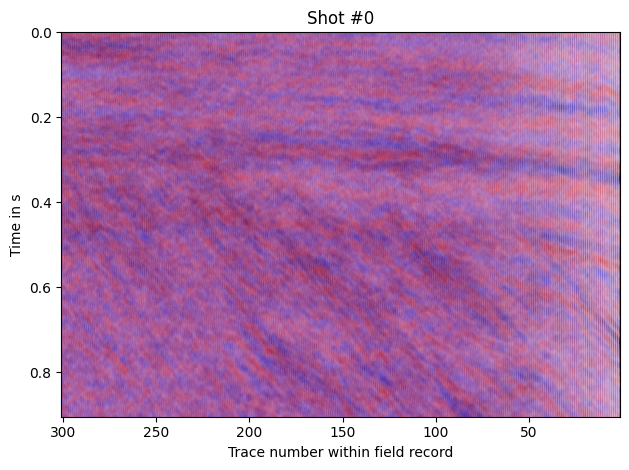

In [121]:

fig, ax = plt.subplots(1, 1)
data = ens["data"]
vmm = np.percentile(data, 97.0)
norm = cm.colors.Normalize(vmax=vmm, vmin=-vmm)
ax.imshow(data.T, cmap="seismic", origin="upper", aspect="auto", norm=norm,
          extent=[ens["tracf"][0], ens["tracf"][-1], sampling_times[-1], sampling_times[0]])
ax.set_title(f"Shot #{ens['fldr'][0]}")
ax.set_xlabel("Trace number within field record")
ax.set_ylabel("Time in s")
plt.tight_layout()
plt.show()